**LABORATORIO 3: EDA (ANÁLISIS EXPLORATORIO DE AUDIO)**

## 1. Configuración Inicial

In [ ]:
# 📥 Instalación de dependencias (ejecutar una vez)
!pip install librosa numpy matplotlib scipy ipywidgets
# 📚 Importación de módulos
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
from scipy import signal
from scipy import fft
from IPython.display import Audio, display
import ipywidgets as widgets
from ipywidgets import interact
import seaborn as sns
import pandas as pd
from sklearn.decomposition import PCA

# ⚙️ Configuración de visualización
plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['font.size'] = 11
plt.style.use('seaborn-v0_8-whitegrid')

print("✅ Entorno listo. ¡Comencemos!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 17.7 MB/s eta 0:00:00
✅ Entorno listo. ¡Comencemos!


## 2. Parte 1: Generación de Dataset Sintético


In [ ]:
def generar_dataset_sintetico(n_muestras=100, sr=22050, duracion=2.0):
    """
    Genera dataset sintético con 3 clases:
    - Clase 0: Tono grave (200-400 Hz)
    - Clase 1: Tono medio (600-1000 Hz)
    - Clase 2: Tono agudo (1500-2500 Hz)
    """
    dataset = []
    t = np.linspace(0, duracion, int(sr * duracion), endpoint=False)

    for i in range(n_muestras):
        for clase in range(3):

            # Frecuencias según clase
            if clase == 0:  # Grave
                f1 = np.random.uniform(200, 300)
                f2 = np.random.uniform(400, 500)
            elif clase == 1:  # Medio
                f1 = np.random.uniform(600, 800)
                f2 = np.random.uniform(1000, 1200)
            else:  # Agudo
                f1 = np.random.uniform(1500, 2000)
                f2 = np.random.uniform(2500, 3000)

            # Generar señal con 2 frecuencias + ruido
            señal = (0.6 * np.sin(2 * np.pi * f1 * t) +
                     0.3 * np.sin(2 * np.pi * f2 * t) +
                     0.05 * np.random.randn(len(t)))

            # Normalizar
            señal = señal / np.max(np.abs(señal)) * 0.9

            dataset.append({
                'audio': señal,
                'sr': sr,
                'clase': clase,
                'etiqueta': ['grave', 'medio', 'agudo'][clase],
                'f1_real': f1,
                'f2_real': f2
            })

    print(f"✅ Dataset generado: {len(dataset)} muestras, 3 clases")
    return dataset

# Generar dataset
dataset = generar_dataset_sintetico(n_muestras=50)

✅ Dataset generado: 150 muestras, 3 clases


## 3. Parte 2: Extracción Masiva de Features

In [ ]:
def extraer_features_completas(audio, sr):
    """Extrae todas las features relevantes para EDA"""
    features = {}

    # Features temporales
    features['rms'] = librosa.feature.rms(y=audio)[0].mean()
    features['zcr'] = librosa.feature.zero_crossing_rate(audio)[0].mean()

    # Features espectrales
    features['spectral_centroid'] = librosa.feature.spectral_centroid(y=audio, sr=sr)[0].mean()
    features['spectral_bandwidth'] = librosa.feature.spectral_bandwidth(y=audio, sr=sr)[0].mean()
    features['spectral_rolloff'] = librosa.feature.spectral_rolloff(y=audio, sr=sr)[0].mean()
    features['spectral_flatness'] = librosa.feature.spectral_flatness(y=audio)[0].mean()

    # MFCCs (primeros 5)
    mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=5)
    for i in range(5):
        features[f'mfcc_{i}'] = mfccs[i].mean()

    # Duración
    features['duracion'] = len(audio) / sr

    return features

# Extraer features de todo el dataset
print("🔄 Extrayendo features...")
features_df = []

for i, muestra in enumerate(dataset):
    feats = extraer_features_completas(muestra['audio'], muestra['sr'])
    feats['clase'] = muestra['clase']
    feats['etiqueta'] = muestra['etiqueta']
    feats['id'] = i
    features_df.append(feats)

    if (i+1) % 50 == 0:
        print(f"  Progreso: {i+1}/{len(dataset)}")

# Convertir a DataFrame
df = pd.DataFrame(features_df)
print(f"✅ Features extraídas: {df.shape[0]} muestras × {df.shape[1]} columnas")

# Mostrar primeras filas
print("\n📋 Primeras muestras:")
print(df.head())

🔄 Extrayendo features...
  Progreso: 50/150
  Progreso: 100/150
  Progreso: 150/150
✅ Features extraídas: 150 muestras × 15 columnas

📋 Primeras muestras:
        rms       zcr  spectral_centroid  spectral_bandwidth  \
0  0.413276  0.036879        3233.836931         3516.207204   
1  0.391578  0.074696        3503.384336         3304.997249   
2  0.409900  0.157047        4022.952809         2959.575110   
3  0.391806  0.036666        3239.081214         3526.426727   
4  0.410904  0.069336        3495.139464         3329.255205   

   spectral_rolloff  spectral_flatness     mfcc_0     mfcc_1     mfcc_2  \
0       8058.244376           0.006719 -84.533560  24.012920  23.528434   
1       8079.406317           0.006843 -89.438285  15.505773  -3.756939   
2       8113.562433           0.006821 -91.055952  -3.783635 -18.096117   
3       8090.915443           0.006712 -90.416632  24.052289  23.642839   
4       8100.320750           0.006892 -85.127490  15.590327  -1.226361   

      mfc

## 4. Parte 3: Estadísticos Descriptivos

📊 ESTADÍSTICOS DESCRIPTIVOS POR CLASE


RMS:
            mean     std     min     max
etiqueta                                
agudo     0.4040  0.0062  0.3865  0.4162
grave     0.4040  0.0066  0.3880  0.4166
medio     0.4052  0.0077  0.3807  0.4204
------------------------------------------------------------

ZCR:
            mean     std     min     max
etiqueta                                
agudo     0.1582  0.0118  0.1396  0.1782
grave     0.0383  0.0010  0.0363  0.0408
medio     0.0681  0.0044  0.0615  0.0752
------------------------------------------------------------

SPECTRAL_CENTROID:
               mean      std        min        max
etiqueta                                          
agudo     4024.6089  50.3947  3927.7635  4135.2664
grave     3256.9427  13.8480  3228.2612  3280.8058
medio     3478.7973  23.1998  3436.7959  3530.3874
------------------------------------------------------------

SPECTRAL_BANDWIDTH:
               mean      std        min        max
etiqueta 

/tmp/ipykernel_823/3627232659.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[idx].legend(title='Clase')
/tmp/ipykernel_823/3627232659.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[idx].legend(title='Clase')
/tmp/ipykernel_823/3627232659.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[idx].legend(title='Clase')
/tmp/ipykernel_823/3627232659.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[idx].legend(title='Clase')
/tmp/ipykernel_823/3627232659.py:20:

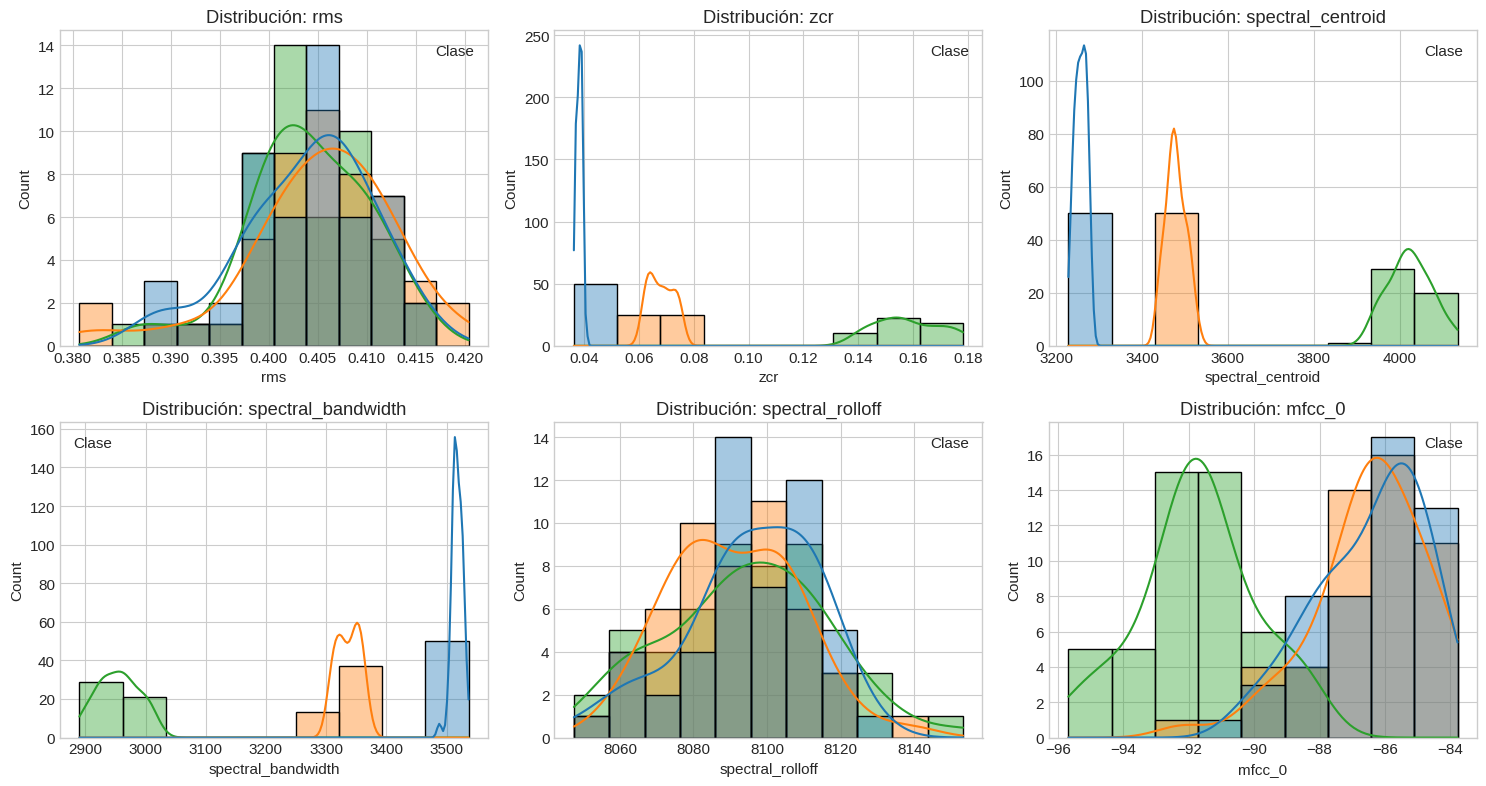

💡 Observa si las distribuciones se superponen o están separadas entre clases.


In [ ]:
# Estadísticos generales por clase
print("📊 ESTADÍSTICOS DESCRIPTIVOS POR CLASE\n")
print("="*80)

features_numericas = ['rms', 'zcr', 'spectral_centroid', 'spectral_bandwidth',
                      'spectral_rolloff', 'mfcc_0', 'mfcc_1']

for feature in features_numericas:
    print(f"\n{feature.upper()}:")
    print(df.groupby('etiqueta')[feature].agg(['mean', 'std', 'min', 'max']).round(4))
    print("-" * 60)

# Visualización: Histogramas por clase
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, feature in enumerate(features_numericas[:6]):
    sns.histplot(data=df, x=feature, hue='etiqueta', kde=True, ax=axes[idx], alpha=0.4)
    axes[idx].set_title(f'Distribución: {feature}')
    axes[idx].legend(title='Clase')

plt.tight_layout()
plt.show()

print("💡 Observa si las distribuciones se superponen o están separadas entre clases.")

## 5. Parte 4: Aplicación de FFT - Análisis Frecuencial

📋 FFT - Ejemplo de cada clase:


CLASE: GRAVE (f1=222 Hz, f2=428 Hz)


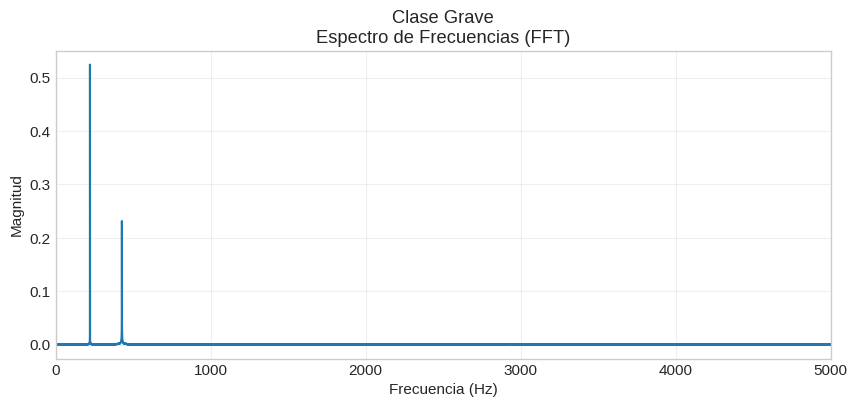

🔍 Picos principales detectados:
  • 222.0 Hz (magnitud: 0.524)
  • 428.0 Hz (magnitud: 0.231)

CLASE: MEDIO (f1=771 Hz, f2=1188 Hz)


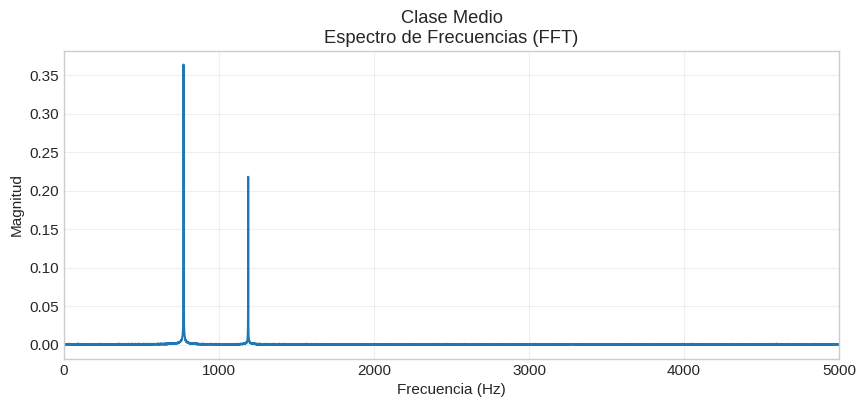

🔍 Picos principales detectados:
  • 771.0 Hz (magnitud: 0.364)
  • 1188.0 Hz (magnitud: 0.218)

CLASE: AGUDO (f1=1745 Hz, f2=2733 Hz)


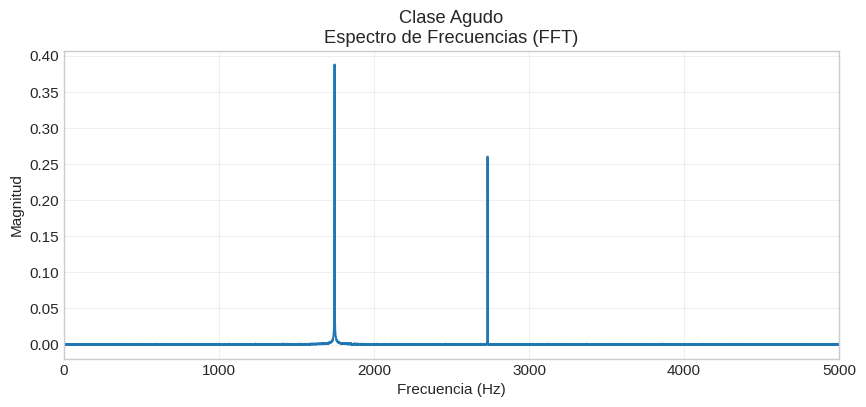

🔍 Picos principales detectados:
  • 1745.5 Hz (magnitud: 0.387)
  • 2732.5 Hz (magnitud: 0.260)


In [ ]:
def visualizar_fft_ejemplo(audio, sr, titulo="FFT"):
    """Calcula y visualiza la FFT de una señal"""

    # Calcular FFT
    N = len(audio)
    T = 1.0 / sr
    yf = fft.fft(audio)
    xf = fft.fftfreq(N, T)[:N//2]

    # Magnitud (solo mitad positiva)
    magnitud = 2.0/N * np.abs(yf[0:N//2])

    # Gráfico
    plt.figure(figsize=(10, 4))
    plt.plot(xf, magnitud, linewidth=1.5)
    plt.title(f'{titulo}\nEspectro de Frecuencias (FFT)')
    plt.xlabel('Frecuencia (Hz)')
    plt.ylabel('Magnitud')
    plt.xlim(0, 5000)  # Limitar a 5 kHz para mejor visualización
    plt.grid(True, alpha=0.3)
    plt.show()

    # Encontrar picos principales
    from scipy.signal import find_peaks
    peaks, properties = find_peaks(magnitud, height=0.1, distance=100)
    print(f"🔍 Picos principales detectados:")
    for peak in peaks[:5]:  # Mostrar top 5
        print(f"  • {xf[peak]:.1f} Hz (magnitud: {magnitud[peak]:.3f})")

# Seleccionar un ejemplo de cada clase
print("📋 FFT - Ejemplo de cada clase:\n")

for clase in range(3):
    idx = df[df['clase'] == clase].index[0]
    muestra = dataset[idx]

    print(f"\n{'='*60}")
    print(f"CLASE: {muestra['etiqueta'].upper()} (f1={muestra['f1_real']:.0f} Hz, f2={muestra['f2_real']:.0f} Hz)")
    print('='*60)

    visualizar_fft_ejemplo(muestra['audio'], muestra['sr'],
                           f"Clase {muestra['etiqueta'].capitalize()}")

## 6. Parte 5: Espectrogramas STFT

🎨 ESPECTROGRAMAS COMPARATIVOS



/tmp/ipykernel_823/3274810555.py:57: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


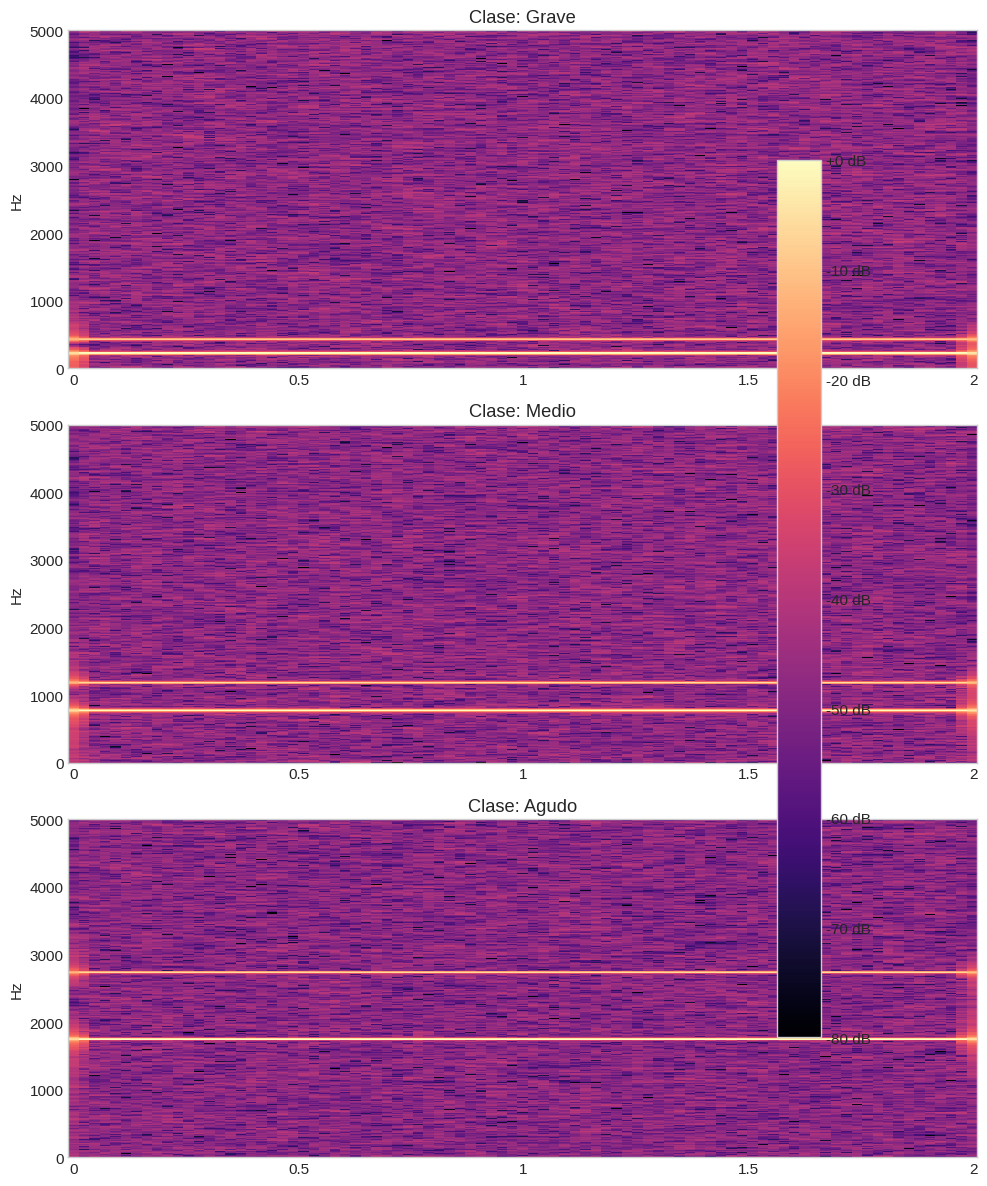

💡 Observa las bandas horizontales brillantes: son las frecuencias dominantes.


In [ ]:
def visualizar_espectrograma(audio, sr, titulo="Espectrograma"):
    """Genera espectrograma usando STFT"""

    # Calcular STFT
    D = librosa.stft(audio, n_fft=2048, hop_length=512, window='hann')
    S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

    # Gráfico
    plt.figure(figsize=(10, 5))
    librosa.display.specshow(
        S_db,
        sr=sr,
        x_axis='time',
        y_axis='hz',
        hop_length=512,
        cmap='magma'
    )
    plt.title(titulo)
    plt.xlabel('Tiempo (s)')
    plt.ylabel('Frecuencia (Hz)')
    plt.colorbar(format='%+2.0f dB')
    plt.ylim(0, 5000)  # Limitar a 5 kHz
    plt.tight_layout()
    plt.show()


# Comparar espectrogramas de las 3 clases
print("🎨 ESPECTROGRAMAS COMPARATIVOS\n")

fig, axes = plt.subplots(3, 1, figsize=(10, 12))

for idx, clase in enumerate(range(3)):
    idx_df = df[df['clase'] == clase].index[0]
    muestra = dataset[idx_df]

    # Calcular STFT
    D = librosa.stft(muestra['audio'], n_fft=2048, hop_length=512)
    S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

    # Mostrar
    img = librosa.display.specshow(
        S_db,
        sr=muestra['sr'],
        x_axis='time',
        y_axis='hz',
        ax=axes[idx],
        cmap='magma',
        hop_length=512
    )

    axes[idx].set_title(f"Clase: {muestra['etiqueta'].capitalize()}")
    axes[idx].set_xlabel('')
    axes[idx].set_ylim(0, 5000)

plt.colorbar(img, ax=axes, format='%+2.0f dB', shrink=0.95)

plt.tight_layout()
plt.show()

print("💡 Observa las bandas horizontales brillantes: son las frecuencias dominantes.")

## 7. Parte 6: Matriz de Correlación

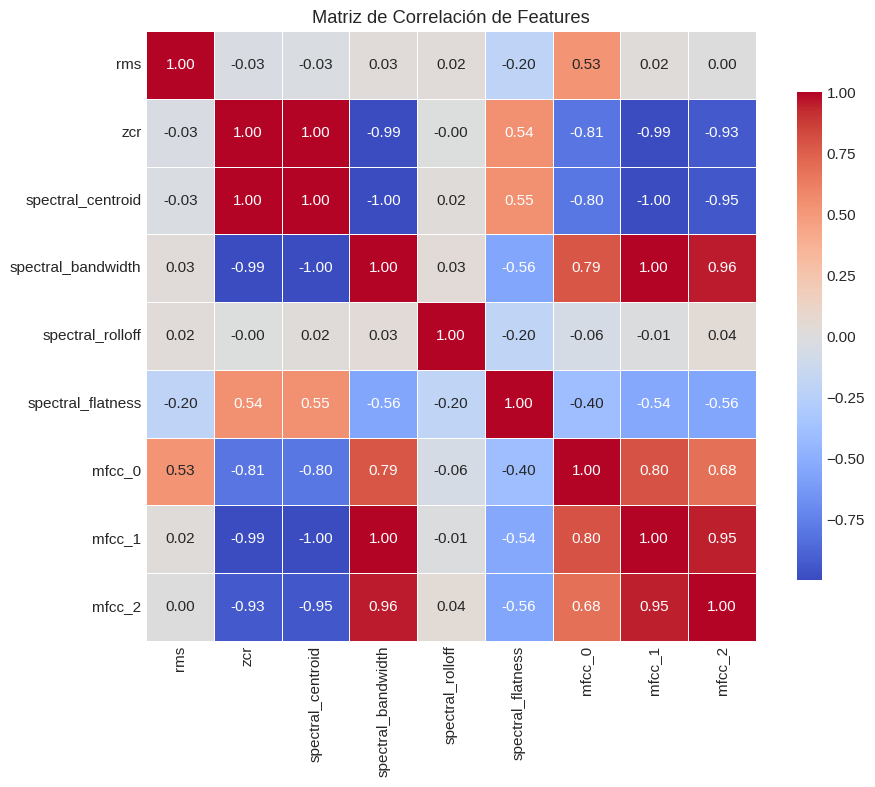


🔍 CORRELACIONES ALTAS (|r| > 0.7):
zcr                  ↔ spectral_centroid   : r = 0.997
zcr                  ↔ spectral_bandwidth  : r = -0.995
zcr                  ↔ mfcc_0              : r = -0.806
zcr                  ↔ mfcc_1              : r = -0.994
zcr                  ↔ mfcc_2              : r = -0.929
spectral_centroid    ↔ spectral_bandwidth  : r = -0.998
spectral_centroid    ↔ mfcc_0              : r = -0.800
spectral_centroid    ↔ mfcc_1              : r = -0.998
spectral_centroid    ↔ mfcc_2              : r = -0.947
spectral_bandwidth   ↔ mfcc_0              : r = 0.789
spectral_bandwidth   ↔ mfcc_1              : r = 0.996
spectral_bandwidth   ↔ mfcc_2              : r = 0.958
mfcc_0               ↔ mfcc_1              : r = 0.803
mfcc_1               ↔ mfcc_2              : r = 0.946

💡 Features altamente correlacionadas pueden ser redundantes.
📊 PCA - Varianza explicada:
 PC1: 99.65%
 PC2: 0.30%
 Total: 99.95%


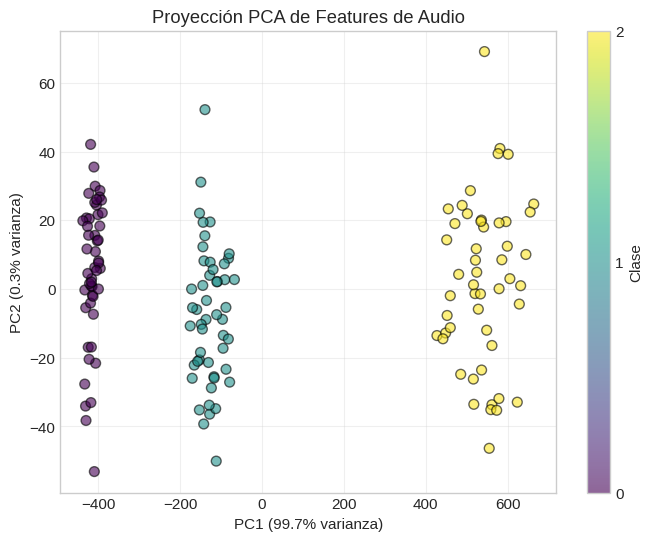


💡 Si las clases están separadas en PCA, las features son discriminativas.


In [ ]:
# Seleccionar solo columnas numéricas para correlación
cols_correlacion = [
    'rms', 'zcr', 'spectral_centroid', 'spectral_bandwidth',
    'spectral_rolloff', 'spectral_flatness',
    'mfcc_0', 'mfcc_1', 'mfcc_2'
]

# Calcular matriz de correlación
corr_matrix = df[cols_correlacion].corr()

# Visualizar heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title('Matriz de Correlación de Features')
plt.tight_layout()
plt.show()

# Identificar correlaciones altas
print("\n🔍 CORRELACIONES ALTAS (|r| > 0.7):")
print("=" * 60)

for i in range(len(cols_correlacion)):
    for j in range(i + 1, len(cols_correlacion)):
        corr_val = abs(corr_matrix.iloc[i, j])
        if corr_val > 0.7:
            print(
                f"{cols_correlacion[i]:<20} ↔ {cols_correlacion[j]:<20}: "
                f"r = {corr_matrix.iloc[i, j]:.3f}"
            )

print("\n💡 Features altamente correlacionadas pueden ser redundantes.")




## 8. Parte 7: Visualización Multidimensional con PCA

📊 PCA - Varianza explicada:
 PC1: 99.65%
 PC2: 0.30%
 Total: 99.95%


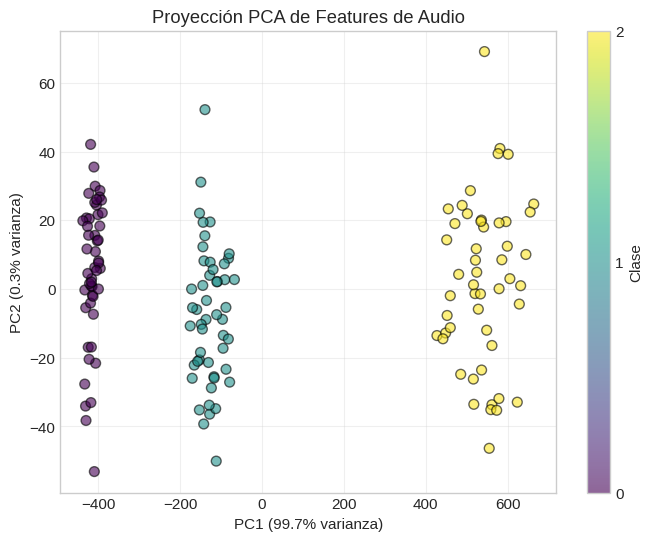


💡 Si las clases están separadas en PCA, las features son discriminativas.


In [ ]:
# 8. Parte 7: Visualización Multidimensional con PCA

# Preparar datos para PCA
features_pca = [
    'rms', 'zcr', 'spectral_centroid', 'spectral_bandwidth',
    'spectral_rolloff', 'mfcc_0', 'mfcc_1', 'mfcc_2'
]

X = df[features_pca].values
y = df['clase'].values

# Aplicar PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Explicar varianza
print("📊 PCA - Varianza explicada:")
print(f" PC1: {pca.explained_variance_ratio_[0]:.2%}")
print(f" PC2: {pca.explained_variance_ratio_[1]:.2%}")
print(f" Total: {sum(pca.explained_variance_ratio_):.2%}")

# Visualizar proyección
plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y,
    cmap='viridis',
    alpha=0.6,
    s=50,
    edgecolors='k'
)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} varianza)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} varianza)')
plt.title('Proyección PCA de Features de Audio')

plt.colorbar(scatter, ticks=[0, 1, 2], label='Clase')
plt.grid(True, alpha=0.3)
plt.show()

print("\n💡 Si las clases están separadas en PCA, las features son discriminativas.")

## 9. Parte 8: Detección de Outliers

🔍 DETECCIÓN DE OUTLIERS (Método IQR)


SPECTRAL_CENTROID:
 Rango normal: [2183.0422, 5078.7873]
 Outliers detectados: 0 (0.0%)

RMS:
 Rango normal: [0.3872, 0.4228]
 Outliers detectados: 3 (2.0%)
 IDs: [55, 110, 112]...

ZCR:
 Rango normal: [-0.1255, 0.3135]
 Outliers detectados: 0 (0.0%)


/tmp/ipykernel_823/2189041145.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_823/2189041145.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_823/2189041145.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


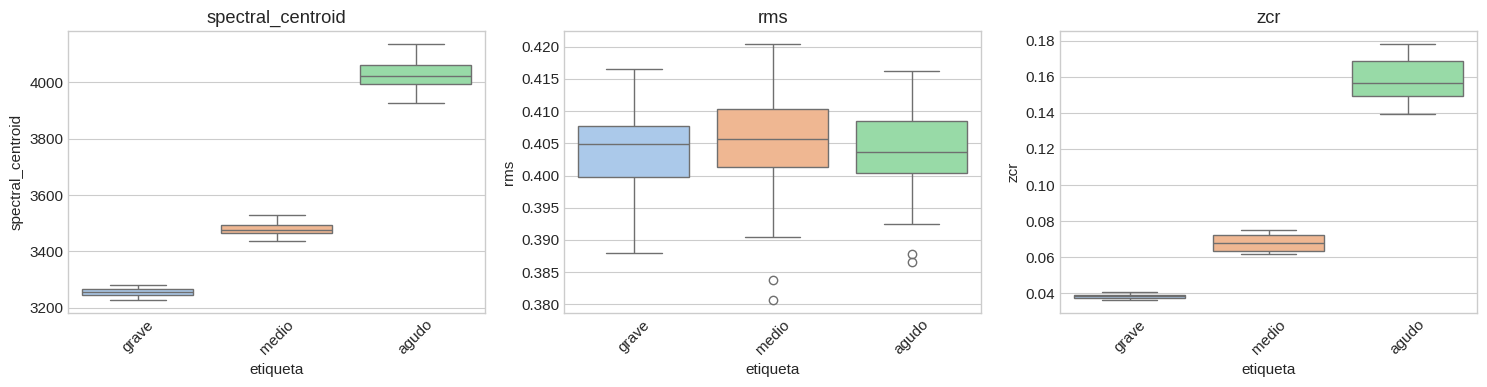


💡 Los outliers pueden ser errores de grabación o eventos raros interesantes.


In [ ]:
def detectar_outliers_iqr(df, columna):
    """Detecta outliers usando el método IQR"""

    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1

    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR

    outliers = df[
        (df[columna] < limite_inf) | (df[columna] > limite_sup)
    ]

    return outliers, limite_inf, limite_sup


# Detectar outliers en features clave
print("🔍 DETECCIÓN DE OUTLIERS (Método IQR)\n")
print("=" * 70)

features_a_revisar = ['spectral_centroid', 'rms', 'zcr']

for feature in features_a_revisar:
    outliers, lim_inf, lim_sup = detectar_outliers_iqr(df, feature)

    print(f"\n{feature.upper()}:")
    print(f" Rango normal: [{lim_inf:.4f}, {lim_sup:.4f}]")
    print(f" Outliers detectados: {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)")

    if len(outliers) > 0:
        print(f" IDs: {outliers['id'].tolist()[:5]}...")  # Mostrar primeros 5


# Visualizar con boxplot
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, feature in enumerate(features_a_revisar):
    sns.boxplot(
        data=df,
        x='etiqueta',
        y=feature,
        ax=axes[idx],
        palette='pastel'
    )
    axes[idx].set_title(f'{feature}')
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\n💡 Los outliers pueden ser errores de grabación o eventos raros interesantes.")

## 10. Parte 9: Resumen Estadístico del Dataset

In [ ]:
# Crear reporte automático
print("=" * 80)
print("📊 REPORTE COMPLETO DE EDA - DATASET DE AUDIO")
print("=" * 80)

print(f"\n📁 INFORMACIÓN GENERAL:")
print(f" • Total de muestras: {len(df)}")
print(f" • Número de clases: {df['clase'].nunique()}")
print(f" • Features extraídas: {len(features_pca)}")

print(f"\n📊 DISTRIBUCIÓN POR CLASE:")
print(df['etiqueta'].value_counts().to_string())

print(f"\n📏 DURACIÓN:")
print(f" • Media: {df['duracion'].mean():.2f} s")
print(f" • Desviación: {df['duracion'].std():.2f} s")
print(f" • Rango: [{df['duracion'].min():.2f}, {df['duracion'].max():.2f}] s")

print(f"\n🎵 FEATURES PRINCIPALES (media ± std por clase):")

for feature in ['spectral_centroid', 'rms', 'zcr']:
    print(f"\n {feature.upper()}:")

    for clase in df['etiqueta'].unique():
        media = df[df['etiqueta'] == clase][feature].mean()
        std = df[df['etiqueta'] == clase][feature].std()

        print(f"\t{clase:8s}: {media:.4f} ± {std:.4f}")

print("\n" + "=" * 80)
print("✅ EDA completado. Dataset listo para modelado.")
print("=" * 80)

📊 REPORTE COMPLETO DE EDA - DATASET DE AUDIO

📁 INFORMACIÓN GENERAL:
 • Total de muestras: 150
 • Número de clases: 3
 • Features extraídas: 8

📊 DISTRIBUCIÓN POR CLASE:
etiqueta
grave    50
medio    50
agudo    50

📏 DURACIÓN:
 • Media: 2.00 s
 • Desviación: 0.00 s
 • Rango: [2.00, 2.00] s

🎵 FEATURES PRINCIPALES (media ± std por clase):

 SPECTRAL_CENTROID:
	grave   : 3256.9427 ± 13.8480
	medio   : 3478.7973 ± 23.1998
	agudo   : 4024.6089 ± 50.3947

 RMS:
	grave   : 0.4040 ± 0.0066
	medio   : 0.4052 ± 0.0077
	agudo   : 0.4040 ± 0.0062

 ZCR:
	grave   : 0.0383 ± 0.0010
	medio   : 0.0681 ± 0.0044
	agudo   : 0.1582 ± 0.0118

✅ EDA completado. Dataset listo para modelado.


## 11. ACTIVIDADES

**1.**	Interpretación FFT: En el espectro de la clase "grave", observas picos en 250 Hz y 450 Hz. Explica (en este dataset los valores son de 222 hz y 428 hz:

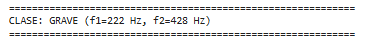
- ¿Cuál es la frecuencia fundamental?
Es 222 Hz, porque es la frecuencia más baja y dominante.

- ¿Qué representa el segundo pico?
El segundo pico en 428 Hz representa la segunda frecuencia que el código generó intencionalmente (f2), no es un armónico puro porque un armónico de 222 Hz sería 444 Hz (el doble).

- Si agregas un pico en 750 Hz, ¿cómo cambiaría el timbre?
Si agregás un pico en 750 Hz el timbre cambiaría porque estarías sumando una tercera frecuencia al sonido. El tono fundamental seguiría siendo 222 Hz pero el sonido se volvería más complejo y brillante, similar a como una guitarra suena más rica que un tono puro de sintetizador por tener más armónicos.

**2.**	Análisis de Correlación: La matriz muestra que spectral_centroid y spectral_rolloff tienen r=0.89. Si esto fuera asi sucederia porque ambas describen cómo se distribuye la energía en frecuencia y miden aspectos relacionados de las frecuencias altas.

SIn embargo en este dataset observamos que la energía está concentrada en pocos picos, por lo que el rolloff (que depende de la energía acumulada del espectro) no necesariamente crece al mismo ritmo que el centroid. En la matriz de correlacion generada con estos datos la correlacion mas fuerte esta entre zcr y spectral_centroid que tienen r=99, por lo que analizamos esa correlacion.

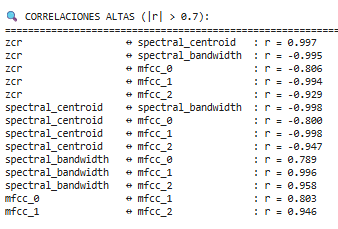

- ¿Por qué están tan correlacionadas?
Porque ambas estan relacionadas con el contenido frecuencial de la señal e indican que tan agudo es el sonido. un ZRC alto indica que la frecuencia cruza el 0 muchas veces, es decir que oscila rapido, siendo una frecuencia alta. El centroid indica el centro de gravedad de las frecuencias, cuando esta en frecuencias altas el sonido es agudo.

- ¿Eliminarías una? Justifica.
Eliminaría ZCR porque spectral_centroid es más interpretable y da información equivalente.

- ¿En qué situación mantendrías ambas?
Las mantendría en una etapa exploratoria para analizar mejor el comportamiento del espectro o comparar cuál aporta más información antes de decidir eliminar alguna, o en caso de utilizar modelos que no se vean afectados por la redundancia.

**3.**	PCA: El PCA muestra que PC1 explica 65% de la varianza y PC2 explica 20%.
Al generar el dataset aleatorio obtuvimos un PC1: 99.65% y PC2: 0.30%
 Total: 99.95%

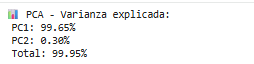

- ¿Qué significa esto?
PC1 explica el 99,65% de la variabilidad del dataset y PC2 explica el 0.30%,Significa que con las dos primeras componentes capturamos el 99,95%% de la variabilidad del dataset.

- ¿Es suficiente con 2 componentes para visualizar el dataset?
Con 2 componentes es suficiente para visualizar el dataset porque el 99,95% de la varianza está representado.

- ¿Qué feature contribuye más a PC1 si su coeficiente es el mayor?
La feature con mayor coficiente en este dataset es spectral_centroid, significa que es la variable que más explica las diferencias entre las clases, o sea la más importante para distinguir grave de medio de agudo.


**4.**	Outliers: Detectaste 5% de outliers en zcr.
EN este dataset generado los outliers aparecen en RMS (2%)

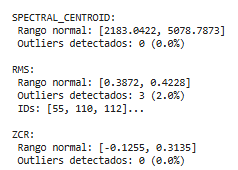

- ¿Los eliminarías automáticamente?, ¿Por qué sí o por qué no?
No los eliminaría automáticamente porque podrían ser udios con volumen inusualmente bajo o alto o errores de generación del audio sintético.

- ¿Qué harías antes de decidir?
Revisar el audio del outlier (escucharlo, ver graficos, etc) y analizar si tiene sentido en el contexto o es un error.

- Propón una estrategia de manejo de outliers.
Mi estrategia sería:
1. Identificar outliers con IQR
2. Revisar manualmente los casos extremos
3. Los que son errores técnicos eliminarlos
4. Los que son casos raros reales conservarlos